In [ ]:
!git clone https://github.com/edrosten/squassh.git
import sys
import os
sys.path.insert(0, '/content/squassh')
os.environ["OVERRIDE_UNCLEAN_REPO"]="1"
%pip install pystrict plotly

Cloning into 'squassh'...
remote: Enumerating objects: 453, done.
remote: Counting objects: 100% (453/453), done.
remote: Compressing objects: 100% (375/375), done.
remote: Total 453 (delta 51), reused 443 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (453/453), 10.00 MiB | 33.58 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Filtering content: 100% (40/40), 239.45 MiB | 81.27 MiB/s, done.


In [ ]:
from typing import cast
import torch
import torch._dynamo
import resi_data         # noqa
import mark_bates_data   # noqa
import train
import network
import device
from localisation_data import LocalisationDataSetMultipleDan6

## Load in the dataset

Load data and select some rendering parameters to give a useful rendition.

In [ ]:
nupc3d = [t.to(device.device).half() for t in resi_data.load_3d()]

rejection = 1.0

data_parameters = train.DataParametersXYYZ(
    image_size_xy = 64,
    image_size_z = 32,
    nm_per_pixel_xy = 3.9,
    z_scale = 2
)

## First phase: rapid training with a small model

Initial training starts with a small model of 35 points and decreases the rendering resolution from 65 to 34nm and then slowly to 13nm. Since there are so few points, the intensities are fixed.

In [ ]:
net, parameterisation =network.PredictReconstructionStretchExpandValidDan6(model_size=35, **vars(data_parameters), data=nupc3d)
net._model_intensities.requires_grad=False  # pylint: disable=protected-access
parameterisation.max_stretch_factor_axis = 2.0
parameterisation.max_stretch_factor_expand = 1.0
_ = net.to(device.device)


### Fast training schedule

The schedule starts very coarse and somwhat rapidly decays the clur down to the final value of 13nm

In [ ]:
params_initial = train.TrainingParameters()
params_initial.batch_size = 160
params_initial.validity_weight=rejection

params_initial.schedule[0].epochs = 90
params_initial.schedule[0].initial_psf = 65.0
params_initial.schedule[0].final_psf = 33.8
params_initial.schedule[0].psf_step_every= 3
params_initial.schedule[0].initial_lr= 0.0001
params_initial.schedule[0].final_lr= 0.0001

params_initial.schedule.append(train.TrainingSegment())
params_initial.schedule[1].epochs = 30
params_initial.schedule[1].initial_psf = 24.7
params_initial.schedule[1].final_psf = 13.0
params_initial.schedule[1].psf_step_every= 10
params_initial.schedule[1].initial_lr= 0.0001
params_initial.schedule[1].final_lr= 0.0001

dataset_initial = LocalisationDataSetMultipleDan6(**vars(data_parameters), data=nupc3d, augmentations=8, device=device.device)

Train the model and save the results in a subdirectory called `phase_0`. The complete run is saved in `logs-`*timestamp*`-`*git hash*.

Note that `torch.compile` has a large effect on speed and especially memory consumption for this code, so this won't run well on GPUs older than the 2000 series (it was tested on a 2080Ti). But `torch.compile` has historically been a bit buggy so it's safer to reset the compuler before using it to avoid it re-using code or ata that it shouldn't.

In [ ]:
torch.compiler.reset()
fast = cast(network.GeneralPredictReconstruction, torch.compile(net))
train.retrain(fast, dataset_initial, params_initial, 'phase_0')

Re-rendering dataset


100%|██████████| 9744/9744 [00:06<00:00, 1411.26it/s]


FWHM = 65.0
61
--------------------------------------------------------------------------------


100%|██████████| 61/61 [03:48<00:00,  3.74s/it]


6
Done epoch 0 phase_0
Time per epoch = 262.5s
Estimated remaining = 8h 40m 33s
FWHM = 65.0
61
--------------------------------------------------------------------------------


...

Done epoch 117 phase_0
Time per epoch = 4.3s
Estimated remaining = 0h 0m 8s
FWHM = 12.999999999999996
61
--------------------------------------------------------------------------------


100%|██████████| 61/61 [00:03<00:00, 15.28it/s]


Done epoch 118 phase_0
Time per epoch = 4.1s
Estimated remaining = 0h 0m 4s
FWHM = 12.999999999999996
61
--------------------------------------------------------------------------------


100%|██████████| 61/61 [00:03<00:00, 15.39it/s]


6
Done epoch 119 phase_0
Time per epoch = 16.4s
Estimated remaining = 0h 0m 0s


## Second training phase

This phase replaces each of the 35 initial points with 20 in roughly the same location, and then continues to train with a 13nm resolution with a slowly decreasing learning rate.

In [ ]:
mult = 20
scatter = 0.01

params_refine = train.TrainingParameters()
params_refine.batch_size = 10
params_refine.validity_weight=rejection

params_refine.schedule[0].epochs = 1000
params_refine.schedule[0].initial_psf = 13.0
params_refine.schedule[0].final_psf = 13.0
params_refine.schedule[0].psf_step_every= 300
params_refine.schedule[0].initial_lr= 0.0002
params_refine.schedule[0].final_lr= 0.00005


scale = net.get_model()[0].abs().max().item()

old_pts, old_weights = (j.detach() for j in net.get_model())

new_pts = torch.nn.functional.interpolate(old_pts.unsqueeze(0).unsqueeze(0), scale_factor=[mult,1]).squeeze(0).squeeze(0)
new_pts += torch.randn(new_pts.shape, device=device.device) * scale * scatter

new_weights = torch.nn.functional.interpolate(old_weights.unsqueeze(0).unsqueeze(0), scale_factor=mult).squeeze(0).squeeze(0)

net.set_model(new_pts, new_weights)
net._model_intensities.requires_grad=True  # pylint: disable=protected-access
parameterisation.max_stretch_factor_expand = 1.3

torch.compiler.reset() # Otherwise it crashes on torch 2.7
fast = cast(network.GeneralPredictReconstruction, torch.compile(net))

dataset_refine = LocalisationDataSetMultipleDan6(**vars(data_parameters), data=nupc3d, augmentations=1, device=device.device)
train.retrain(fast, dataset_refine, params_refine, 'phase_1')



Re-rendering dataset


100%|██████████| 1.22k/1.22k [00:04<00:00, 261it/s]


FWHM = 13.0
122
--------------------------------------------------------------------------------


100%|██████████| 122/122 [03:53<00:00,  1.91s/it]


6
Done epoch 0 phase_1
Time per epoch = 263.8s
Estimated remaining = 73h 12m 4s
FWHM = 13.0
122
--------------------------------------------------------------------------------


...

Done epoch 997 phase_1
Time per epoch = 3.4s
Estimated remaining = 0h 0m 6s
FWHM = 13.0
122
--------------------------------------------------------------------------------


100%|██████████| 122/122 [00:03<00:00, 37.58it/s]


Done epoch 998 phase_1
Time per epoch = 3.3s
Estimated remaining = 0h 0m 3s
FWHM = 13.0
122
--------------------------------------------------------------------------------


100%|██████████| 122/122 [00:03<00:00, 38.11it/s]


6
Done epoch 999 phase_1
Time per epoch = 16.3s
Estimated remaining = 0h 0m 0s


## Plot the results

Plot an XY projection, along with the axis of stretch. Note that the orientation is effectively random.


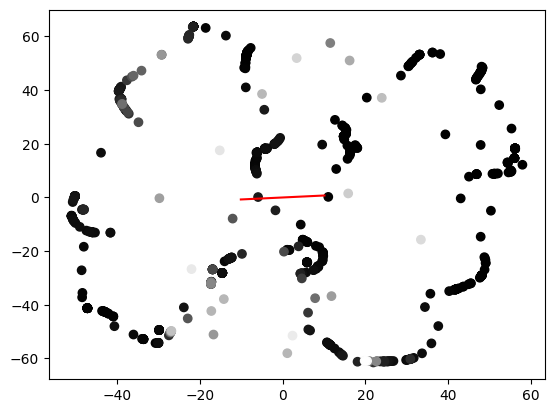

In [ ]:
import matplotlib.pyplot as plt
pts, intensities = [ i.detach().cpu() for i in net.get_model()]
s_intensities, indices = intensities.sort(descending=True) #Sort to low intensity points don't obscure high intensity ones
plt.scatter(pts[indices,0], pts[indices,1], c=-s_intensities, cmap='grey')

ax = parameterisation.get_axis().cpu().detach()
ax = torch.stack([ax*30, ax*-30], 0)

plt.plot(ax[:,0], ax[:,1], 'r')





In [ ]:
from save_ply import make_mesh
v,f = make_mesh(*[i.detach().cpu() for i in net.get_model()], 2.0, size=50)

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
import sys
pio.renderers.default = 'colab' if 'google.colab' in sys.modules else 'notebook'

go.Figure(go.Mesh3d(
    x=v[:,0], y=v[:,1], z=v[:,2],
    i=f[:,0], j=f[:,1], k=f[:,2]
)).show()